# Unit 4 End Project
## Home Loan Data Analysis

In [1]:
%pip install seaborn
%pip install scikit-learn
%pip install pandas
%pip install optuna


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
import re
import pandas as pd
import optuna

import DataProcessing as dp

c:\Users\simsk\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
processor = dp.DataProcessing()
processor.loadFrom_CSV("../data/Lending_Club.txt")
processor.set_target("not.fully.paid")
print(processor.get_data().info())


<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB
None


In [4]:
# Encode non-numeric (Object) columns
excludeList = []
processor.encodeObjectDataTypes(excluded_parameters=excludeList)
print(processor.get_info())
#print(processor.get_data().head())

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB
None


In [5]:
# Update numeric data types
processor.processNumericDataTypes()
print(processor.get_data().head())

   credit.policy             purpose  int.rate  installment  log.annual.inc  \
0              1  debt_consolidation    0.1189   829.099976       11.350407   
1              1         credit_card    0.1071   228.220001       11.082143   
2              1  debt_consolidation    0.1357   366.859985       10.373491   
3              1  debt_consolidation    0.1008   162.339996       11.350407   
4              1         credit_card    0.1426   102.919998       11.299732   

     dti  fico  days.with.cr.line  revol.bal  revol.util  inq.last.6mths  \
0  19.48   737        5639.958496      28854   52.099998               0   
1  14.29   707        2760.000000      33623   76.699997               0   
2  11.63   682        4710.000000       3511   25.600000               1   
3   8.10   712        2699.958252      33667   73.199997               1   
4  14.97   667        4066.000000       4740   39.500000               0   

   delinq.2yrs  pub.rec  not.fully.paid  
0            0        0   

In [6]:
# Check for missing data

missing_data = processor.locateMissingData()

if len(missing_data) == 0 :
    print("No missing data was detected.")
else:
    key_list = list(missing_data.keys())
    tmp_df = processor.getMissingValues(key_list)


No missing data was detected.


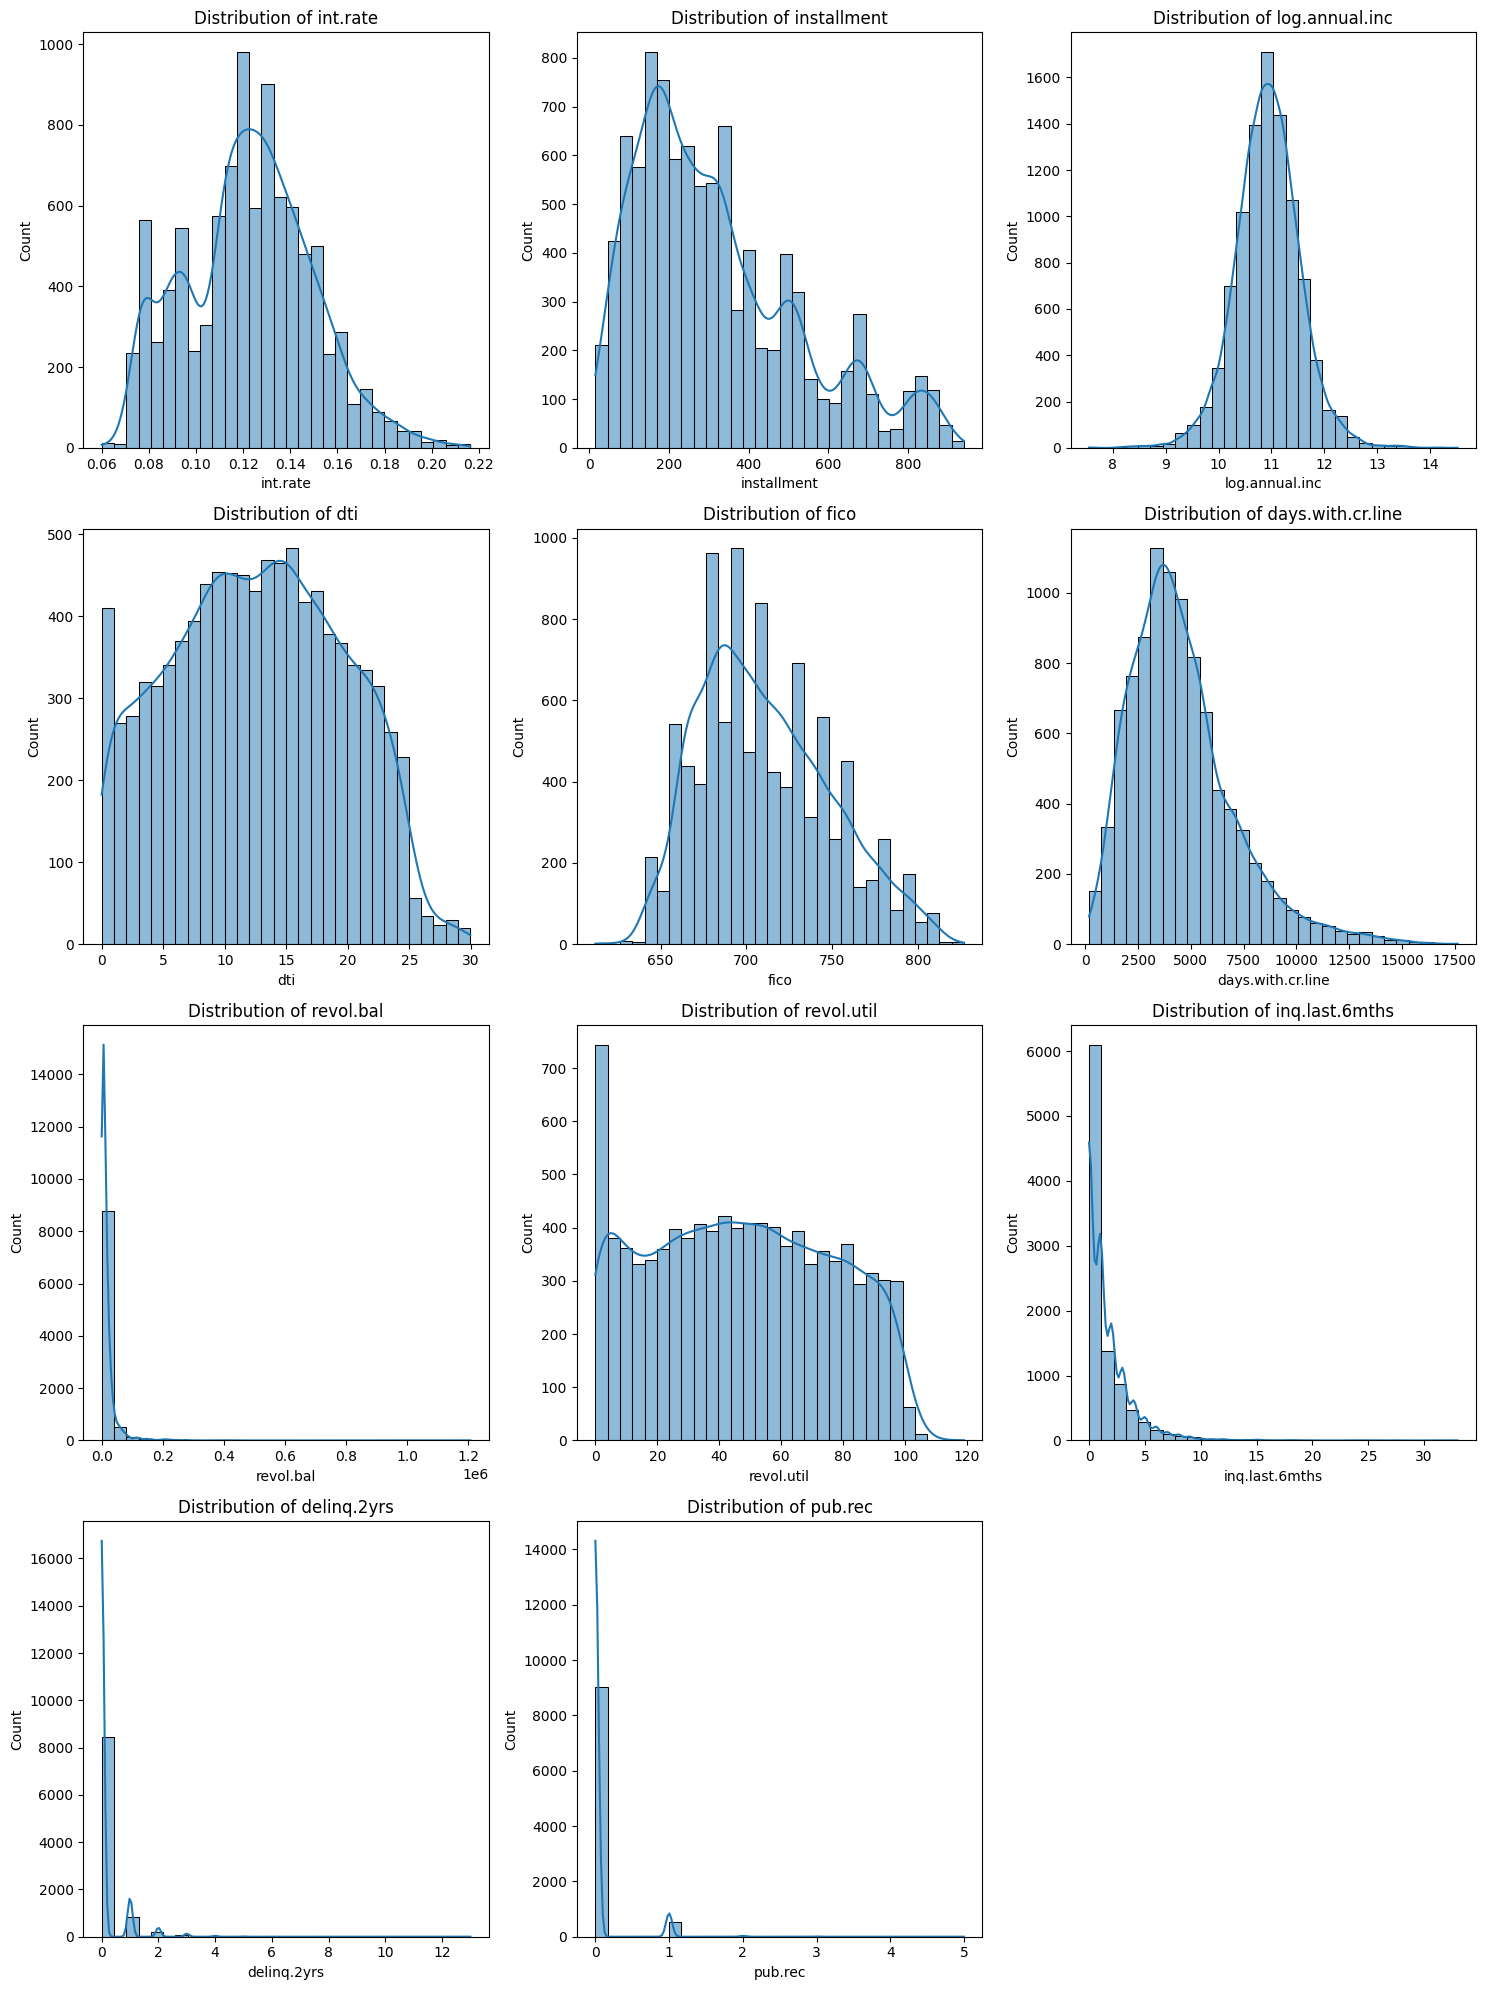

In [7]:
processor.get_histogram_plot(ignore=["credit.policy"])

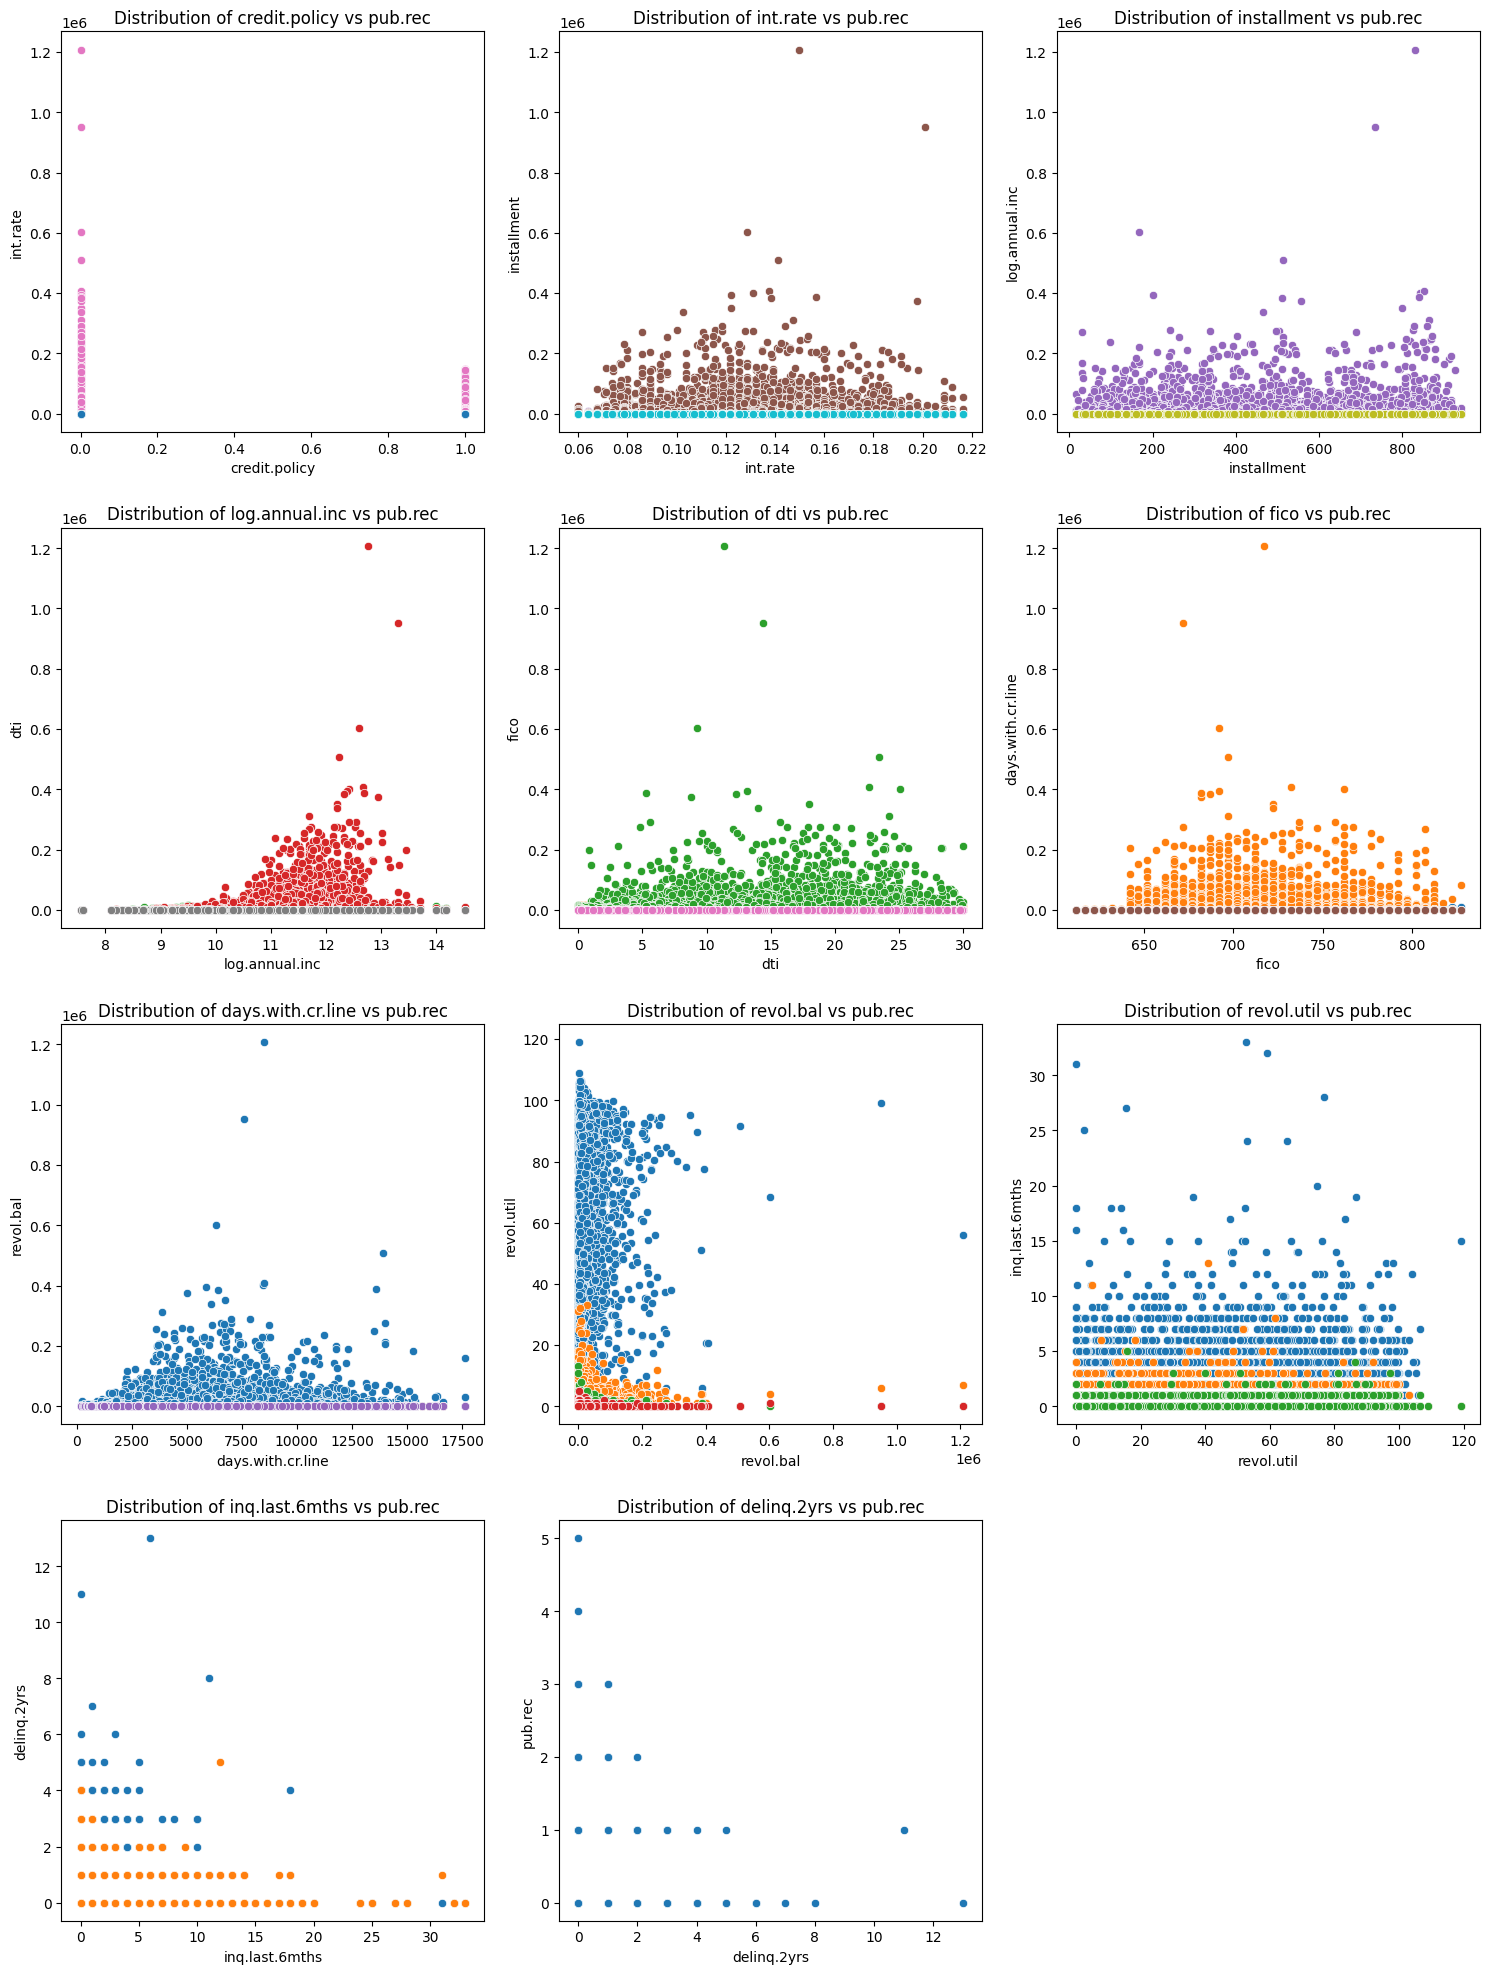

In [8]:
processor.get_scatter_plot()

## Generate Training and Testing Data

In [9]:
scale_features = []
processor.processWithStandardScaler(inplace=False)
#print(processor.get_data().columns.tolist())

In [10]:
processor.set_train_test_data()

print(processor.get_train_features().info())

<class 'pandas.DataFrame'>
Index: 7662 entries, 3485 to 8969
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      7662 non-null   int8   
 1   int.rate           7662 non-null   float32
 2   installment        7662 non-null   float32
 3   log.annual.inc     7662 non-null   float32
 4   dti                7662 non-null   float32
 5   fico               7662 non-null   int16  
 6   days.with.cr.line  7662 non-null   float32
 7   revol.bal          7662 non-null   int64  
 8   revol.util         7662 non-null   float32
 9   inq.last.6mths     7662 non-null   int8   
 10  delinq.2yrs        7662 non-null   int8   
 11  pub.rec            7662 non-null   int8   
dtypes: float32(6), int16(1), int64(1), int8(4)
memory usage: 344.2 KB
None


In [11]:
print(processor.get_test_features().info())

<class 'pandas.DataFrame'>
Index: 1916 entries, 5095 to 5806
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      1916 non-null   int8   
 1   int.rate           1916 non-null   float32
 2   installment        1916 non-null   float32
 3   log.annual.inc     1916 non-null   float32
 4   dti                1916 non-null   float32
 5   fico               1916 non-null   int16  
 6   days.with.cr.line  1916 non-null   float32
 7   revol.bal          1916 non-null   int64  
 8   revol.util         1916 non-null   float32
 9   inq.last.6mths     1916 non-null   int8   
 10  delinq.2yrs        1916 non-null   int8   
 11  pub.rec            1916 non-null   int8   
dtypes: float32(6), int16(1), int64(1), int8(4)
memory usage: 86.1 KB
None


              precision    recall  f1-score   support

           0       0.83      1.00      0.91      1591
           1       0.46      0.02      0.04       325

    accuracy                           0.83      1916
   macro avg       0.65      0.51      0.47      1916
weighted avg       0.77      0.83      0.76      1916



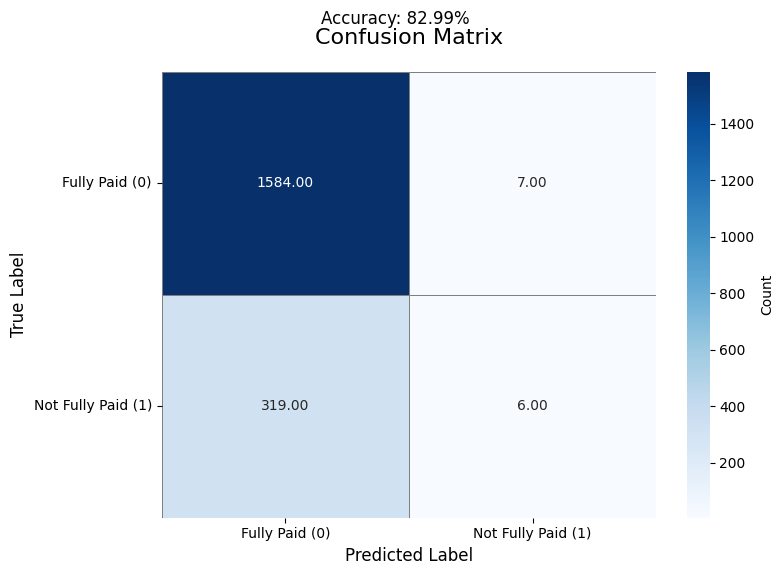

<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted Label', ylabel='True Label'>

In [12]:
model = RandomForestClassifier(n_estimators=100, random_state=315)
model.fit(processor.get_train_features(), processor.get_train_target()) 
predictions = model.predict(processor.get_test_features())
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(processor.get_test_target(), predictions))
processor.plot_confusion_matrix(processor.get_test_target(), predictions)


In [13]:
# Create the deep learning model using Keras functional API
model = processor.build_model(input_shape=processor.get_train_features().shape[1:], 
                              l1_activation='relu',
                              l2_activation='relu',
                              l3_activation='relu',
                              dropout_rate=0.2)
        
test_metrics = ['accuracy', 'Precision', 'Recall', 'f1_score']


In [14]:
# Run optuna trials to find the best hyperparameters for the model
